In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from ydata_profiling import ProfileReport
from sklearn.preprocessing import PowerTransformer, StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_curve, fbeta_score, precision_recall_curve, average_precision_score, precision_score, recall_score
import mlflow
from xgboost import XGBClassifier
import phik
from mlflow.models import infer_signature
from catboost import CatBoostClassifier
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier
import optuna
from sklearn.impute import KNNImputer
from sklearn.metrics import auc

%matplotlib

pd.reset_option('display.max_rows') 
pd.set_option('display.max_columns', None) 

Using matplotlib backend: module://matplotlib_inline.backend_inline


In [2]:
mlflow.set_tracking_uri('http://hostname123.zapto.org:5000')

In [3]:
df = pd.read_csv('../data/Preprocessed_Instagram_Dataset.csv')

In [4]:
df

,Followers,Following,Following/Followers,Posts,Posts/Followers,Bio,Profile Picture,External Link,Mutual Friends,Threads,Labels
0,2,2757,1378.5,0,0,N,N,N,0,N,Bot
1,2,505,252.5,0,0,N,Yes,N,0,N,Scam
2,6786,1782,0.262599469,1589,6051.040404,yes,N,Yes,10,N,Real
3,21,1281,61,0,0,N,Yes,N,0,N,Bot
4,585,1682,2.875213675,2663,926.1920333,yes,N,N,12,Yes,Real
...,...,...,...,...,...,...,...,...,...,...,...
14995,18400,918,0.049891304,1403,28121.1329,N,Yes,Yes,6,Yes,Real
14996,7,481,68.71428571,3,0.043659044,N,N,N,0,N,Scam
14997,6229,131,0.021030663,2418,114974.9771,N,N,Yes,13,N,Real
14998,18408,335,0.018198609,1226,67367.78507,yes,Yes,N,2,Yes,Real


In [5]:
df.isna().sum()

Followers              0
Following              0
Following/Followers    0
Posts                  0
Posts/Followers        0
Bio                    0
Profile Picture        0
External Link          0
Mutual Friends         0
Threads                0
Labels                 0
dtype: int64

In [6]:
from google.cloud import storage
from google.oauth2 import service_account

creds = service_account.Credentials.from_service_account_file(
    "/home/vivaldi/gcp/mlflow-access.json"
)
client = storage.Client(credentials=creds, project=creds.project_id)
buckets = list(client.list_buckets())
print([bucket.name for bucket in buckets])


FileNotFoundError: [Errno 2] No such file or directory: '/home/vivaldi/gcp/mlflow-access.json'

In [7]:
df.dtypes

Followers               int64
Following               int64
Following/Followers    object
Posts                   int64
Posts/Followers        object
Bio                    object
Profile Picture        object
External Link          object
Mutual Friends          int64
Threads                object
Labels                 object
dtype: object

In [8]:
df['Followers'][df['Followers'] == 0] = 1

/tmp/ipykernel_12103/4077598981.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Followers'][df['Followers'] == 0] = 1
/tmp/ipykernel_12103/4077598981.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fro

In [9]:
df = df.drop(columns=['Following/Followers', 'Posts/Followers'])
df['Following/Followers'] = df['Following'] / df['Followers']
df['Posts/Followers'] = df['Posts'] / df['Followers']

In [10]:
df

,Followers,Following,Posts,Bio,Profile Picture,External Link,Mutual Friends,Threads,Labels,Following/Followers,Posts/Followers
0,2,2757,0,N,N,N,0,N,Bot,1378.500000,0.000000
1,2,505,0,N,Yes,N,0,N,Scam,252.500000,0.000000
2,6786,1782,1589,yes,N,Yes,10,N,Real,0.262599,0.234159
3,21,1281,0,N,Yes,N,0,N,Bot,61.000000,0.000000
4,585,1682,2663,yes,N,N,12,Yes,Real,2.875214,4.552137
...,...,...,...,...,...,...,...,...,...,...,...
14995,18400,918,1403,N,Yes,Yes,6,Yes,Real,0.049891,0.076250
14996,7,481,3,N,N,N,0,N,Scam,68.714286,0.428571
14997,6229,131,2418,N,N,Yes,13,N,Real,0.021031,0.388184
14998,18408,335,1226,yes,Yes,N,2,Yes,Real,0.018199,0.066601


In [11]:
obj = df.select_dtypes(include='object')
    

In [12]:
df[['Bio', 'Profile Picture', 'External Link', 'Threads']] = df[['Bio', 'Profile Picture', 'External Link', 'Threads']].applymap(lambda x: 1 if x == 'Yes' else 0)

/tmp/ipykernel_12103/1797653440.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[['Bio', 'Profile Picture', 'External Link', 'Threads']] = df[['Bio', 'Profile Picture', 'External Link', 'Threads']].applymap(lambda x: 1 if x == 'Yes' else 0)


In [13]:
df

,Followers,Following,Posts,Bio,Profile Picture,External Link,Mutual Friends,Threads,Labels,Following/Followers,Posts/Followers
0,2,2757,0,0,0,0,0,0,Bot,1378.500000,0.000000
1,2,505,0,0,1,0,0,0,Scam,252.500000,0.000000
2,6786,1782,1589,0,0,1,10,0,Real,0.262599,0.234159
3,21,1281,0,0,1,0,0,0,Bot,61.000000,0.000000
4,585,1682,2663,0,0,0,12,1,Real,2.875214,4.552137
...,...,...,...,...,...,...,...,...,...,...,...
14995,18400,918,1403,0,1,1,6,1,Real,0.049891,0.076250
14996,7,481,3,0,0,0,0,0,Scam,68.714286,0.428571
14997,6229,131,2418,0,0,1,13,0,Real,0.021031,0.388184
14998,18408,335,1226,0,1,0,2,1,Real,0.018199,0.066601


In [14]:
# profile = ProfileReport(df)
# profile.to_file('../reports/inst.html')

In [15]:
df

,Followers,Following,Posts,Bio,Profile Picture,External Link,Mutual Friends,Threads,Labels,Following/Followers,Posts/Followers
0,2,2757,0,0,0,0,0,0,Bot,1378.500000,0.000000
1,2,505,0,0,1,0,0,0,Scam,252.500000,0.000000
2,6786,1782,1589,0,0,1,10,0,Real,0.262599,0.234159
3,21,1281,0,0,1,0,0,0,Bot,61.000000,0.000000
4,585,1682,2663,0,0,0,12,1,Real,2.875214,4.552137
...,...,...,...,...,...,...,...,...,...,...,...
14995,18400,918,1403,0,1,1,6,1,Real,0.049891,0.076250
14996,7,481,3,0,0,0,0,0,Scam,68.714286,0.428571
14997,6229,131,2418,0,0,1,13,0,Real,0.021031,0.388184
14998,18408,335,1226,0,1,0,2,1,Real,0.018199,0.066601


In [16]:
df = df.drop_duplicates()

interval columns not set, guessing: ['Followers', 'Following', 'Posts', 'Bio', 'Profile Picture', 'External Link', 'Mutual Friends', 'Threads', 'Following/Followers', 'Posts/Followers']


<Axes: >

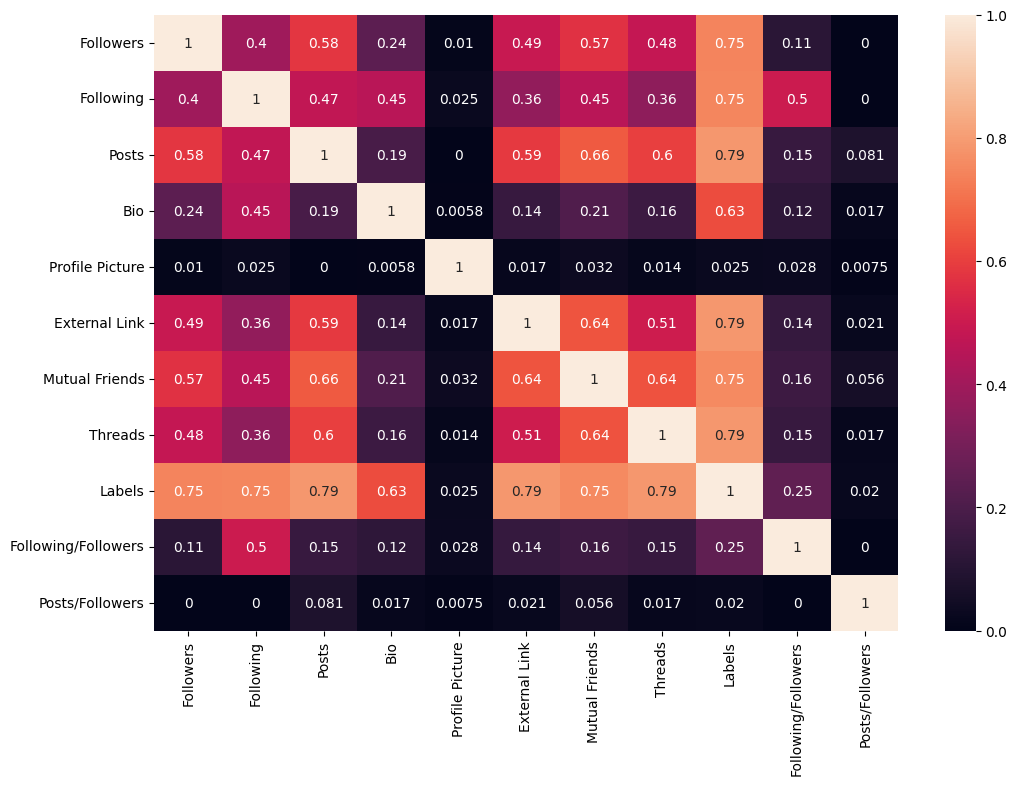

In [17]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.phik_matrix(), annot=True)

In [43]:
df = df.rename(columns={'Profile Picture': 'profile_picture', 'External Link': 'external_link',
                        'Mutual Friends': 'mutual_friends',
                        'Following/Followers': 'Following_Followers',
                        'Posts/Followers': 'Posts_Followers'})

In [44]:
df

,Followers,Following,Posts,Bio,profile_picture,external_link,mutual_friends,Threads,Labels,Following_Followers,Posts_Followers
0,2,2757,0,0,0,0,0,0,Bot,1378.500000,0.000000
1,2,505,0,0,1,0,0,0,Scam,252.500000,0.000000
2,6786,1782,1589,0,0,1,10,0,Real,0.262599,0.234159
3,21,1281,0,0,1,0,0,0,Bot,61.000000,0.000000
4,585,1682,2663,0,0,0,12,1,Real,2.875214,4.552137
...,...,...,...,...,...,...,...,...,...,...,...
14995,18400,918,1403,0,1,1,6,1,Real,0.049891,0.076250
14996,7,481,3,0,0,0,0,0,Scam,68.714286,0.428571
14997,6229,131,2418,0,0,1,13,0,Real,0.021031,0.388184
14998,18408,335,1226,0,1,0,2,1,Real,0.018199,0.066601


In [45]:
X = df.drop(columns='Labels')
y = df['Labels']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:
ord = OrdinalEncoder()

y_train = ord.fit_transform(pd.DataFrame(y_train))
y_test = ord.transform(pd.DataFrame(y_test))

In [47]:
y_train = y_train.reshape(-1).astype(int)

In [48]:
y_test = y_test.reshape(-1).astype(int)

In [49]:
X_train

,Followers,Following,Posts,Bio,profile_picture,external_link,mutual_friends,Threads,Following_Followers,Posts_Followers
13623,14160,965,1255,0,0,1,2,1,0.068150,0.088630
13573,1,693,0,1,0,0,0,0,693.000000,0.000000
2391,29,1081,0,0,1,0,0,0,37.275862,0.000000
4336,18,1330,0,0,1,0,0,0,73.888889,0.000000
9627,5,342,4,1,1,0,0,0,68.400000,0.800000
...,...,...,...,...,...,...,...,...,...,...
5203,15,4628,2,0,1,0,0,0,308.533333,0.133333
13473,5,676,0,0,1,0,0,0,135.200000,0.000000
5403,40,3723,1,0,0,0,0,0,93.075000,0.025000
860,39206,1040,265,0,1,1,8,0,0.026527,0.006759


In [50]:
for i in X_test.columns:
    print(f'{i} : {X_test[i].dtype}')

Followers : int64
Following : int64
Posts : int64
Bio : int64
profile_picture : int64
external_link : int64
mutual_friends : int64
Threads : int64
Following_Followers : float64
Posts_Followers : float64


In [54]:
X_test.to_csv('../api_dfs/X_test.csv', index=False)

In [ ]:
def create_pipeline(trial):
    model = trial.suggest_categorical('model', ['lgbm', 'catboost', 'xgbm', 'logreg'])

    if model == 'lgbm': 
        classifier = LGBMClassifier(random_state=42)

    elif model == 'catboost':
        classifier = CatBoostClassifier(verbose=0, random_state=42)

    elif model == 'xgbm':
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.1)
        min_child_weight = trial.suggest_float('min_child_weight', 1.0, 7.0)
        subsample = trial.suggest_float('subsample', 0.5, 1.0)
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0)
        gamma = trial.suggest_float('gamma', 0, 5)
        reg_alpha = trial.suggest_float('reg_alpha', 0, 5) 
        reg_lambda = trial.suggest_float('reg_lambda', 0, 5)
        classifier = XGBClassifier(
            learning_rate=learning_rate,
            min_child_weight=min_child_weight,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            gamma=gamma,
            reg_alpha=reg_alpha,
            reg_lambda=reg_lambda,
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=42
        )

    else:  # Logistic Regression
        penalty = trial.suggest_categorical('penalty', ['l2', 'l1', 'elasticnet', None])
        c = trial.suggest_float('C', 0.01, 5.0)
        l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
        classifier = LogisticRegression(
            penalty=penalty,
            C=c,
            solver='saga',  # supports all penalties
            max_iter=1000,
            random_state=42,
            l1_ratio=l1_ratio
        )

    pipeline = Pipeline([
        ('scaler', PowerTransformer()),
        ('model', OneVsRestClassifier(classifier))
    ])
    
    return pipeline

def objective(trial):
    m_classifier = create_pipeline(trial)
    score = cross_val_score(m_classifier, X_train, y_train, cv=5, scoring='f1_macro').mean()
    return score

# Optuna study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

best_trial = study.best_trial
best_pipeline = create_pipeline(best_trial)

# MLflow tracking
mlflow.set_experiment('instagram_s3')

with mlflow.start_run():
    mlflow.log_params(best_trial.params)
    
    # Fit best model
    best_pipeline.fit(X_train, y_train)

    # Predictions
    predictions = best_pipeline.predict(X_test)
    y_pred_proba = best_pipeline.predict_proba(X_test)

    # Metric logging
    metrics_classical = [
        'accuracy', 'f1_macro', 'f1_weighted',
        'precision_macro', 'recall_macro'
    ]
    metrics_proba = ['neg_log_loss', 'roc_auc_ovr']

    for metric in metrics_classical:
        score = cross_val_score(best_pipeline, X_test, y_test, cv=5, scoring=metric).mean()
        mlflow.log_metric(metric, score)

    for metric in metrics_proba:
        score = cross_val_score(best_pipeline, X_test, y_test, cv=5, scoring=metric).mean()
        mlflow.log_metric(metric, score)

    mlflow.log_metric("Best Objective Value", study.best_value)

    # Log model
    example_input = X_test[:5]
    signature = infer_signature(X_test, best_pipeline.predict(X_test))
    mlflow.sklearn.log_model(best_pipeline, "model_pipeline", signature=signature, input_example=example_input)

    # ROC curve logging
    n_classes = len(np.unique(y_train))

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve((y_test == i).astype(int), y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)

        mlflow.log_metric(f"auc_class_{i}", roc_auc)

        plt.figure()
        plt.plot(fpr, tpr, lw=2, label=f'Class {i} (AUC = {roc_auc:.2f})')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - Class {i}")
        plt.legend(loc='lower right')
        mlflow.log_figure(plt.gcf(), f"roc_curve_class_{i}.png")
        plt.close()

In [29]:
preds = pd.read_csv('../predict.csv')
preds

,0
0,1
1,3
2,0
3,2
4,3
...,...
2982,2
2983,3
2984,2
2985,1


In [30]:
print("Accuracy:", accuracy_score(y_test, preds))
print("F1 Macro:", f1_score(y_test, preds, average='macro'))
print("Precision Macro:", precision_score(y_test, preds, average='macro'))
print("Recall Macro:", recall_score(y_test, preds, average='macro'))

Accuracy: 0.9768998995647807
F1 Macro: 0.9767344633848468
Precision Macro: 0.9769883122818783
Recall Macro: 0.9767180535545795


In [46]:
import mlflow
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("test-gcs-artifactss")

with mlflow.start_run():
    with open("test.txt", "w") as f:
        f.write("Hello GCS!")
    mlflow.log_artifact("test.txt")

2025/04/23 23:06:27 INFO mlflow.tracking.fluent: Experiment with name 'test-gcs-artifactss' does not exist. Creating a new experiment.


🏃 View run welcoming-hen-959 at: http://localhost:5000/#/experiments/4/runs/4900b1313504483b9c73c9dc44f1cec2
🧪 View experiment at: http://localhost:5000/#/experiments/4


In [44]:
import os
os.environ.get('GOOGLE_APPLICATION_CREDENTIALS')



'/home/vivaldi/.gcp/mlflow-access.json'

In [43]:
import os
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/home/vivaldi/.gcp/mlflow-access.json"
        